# Modelo de Risco de Defasagem — Notebook de Validação

Objetivo: validar os achados analíticos e construir o modelo preditivo.

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap
import joblib


## 2. Carregar Dados

In [2]:
df = pd.read_csv("/content/dados_limpos_2024.csv")

df.head()


,RA,Nome Anonimizado,Idade,Gênero,Ano ingresso,Fase,Turma,Instituição de ensino,PEDRA_CLASSIFICACAO,INDE_2024_CLEAN,...,IPP,IPV,Defasagem,Ativo/ Inativo,INDE 22,INDE 23,Pedra 22,Pedra 23,ANOS_NA_PM,RISCO_DEFASAGEM
0,RA-1275,Aluno-1275,8,Masculino,2024,ALFA,ALFA A - G0/G1,Pública,Ametista,7.611367,...,5.625,5.446667,0,Cursando,NaN,NaN,NaN,NaN,0,0
1,RA-1276,Aluno-1276,8,Feminino,2024,ALFA,ALFA A - G0/G1,Pública,Topázio,8.002867,...,7.500,7.050000,0,Cursando,NaN,NaN,NaN,NaN,0,0
2,RA-1277,Aluno-1277,8,Masculino,2024,ALFA,ALFA A - G0/G1,Pública,Ametista,7.952200,...,7.500,7.046667,0,Cursando,NaN,NaN,NaN,NaN,0,0
3,RA-868,Aluno-868,8,Masculino,2023,ALFA,ALFA A - G0/G1,Pública,Ametista,7.156367,...,6.875,7.213333,-1,Cursando,NaN,8.63895,NaN,Topázio,1,0
4,RA-1278,Aluno-1278,9,Masculino,2024,ALFA,ALFA A - G0/G1,Pública,Quartzo,5.444200,...,5.000,4.173333,-1,Cursando,NaN,NaN,NaN,NaN,0,0


## 3. Análise Inicial

In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1054 non-null   object 
 1   Nome Anonimizado       1054 non-null   object 
 2   Idade                  1054 non-null   int64  
 3   Gênero                 1054 non-null   object 
 4   Ano ingresso           1054 non-null   int64  
 5   Fase                   1054 non-null   object 
 6   Turma                  1054 non-null   object 
 7   Instituição de ensino  1053 non-null   object 
 8   PEDRA_CLASSIFICACAO    1054 non-null   object 
 9   INDE_2024_CLEAN        1054 non-null   float64
 10  IAN                    1054 non-null   float64
 11  IDA                    1054 non-null   float64
 12  IEG                    1054 non-null   float64
 13  IAA                    1054 non-null   float64
 14  IPS                    1054 non-null   float64
 15  IPP 

,Idade,Ano ingresso,INDE_2024_CLEAN,IAN,IDA,IEG,IAA,IPS,IPP,IPV,Defasagem,INDE 22,INDE 23,ANOS_NA_PM,RISCO_DEFASAGEM
count,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,445.000000,678.000000,1054.000000,1054.000000
mean,12.241935,2022.648008,7.396686,7.459677,6.349858,8.088696,8.543563,6.829670,7.548303,7.354268,-0.484820,7.376840,7.449584,1.351992,0.093928
std,2.741352,1.176055,1.013915,2.511519,2.132045,1.763934,1.491450,1.427893,0.897219,1.048541,0.840147,0.847607,0.852995,1.176055,0.291867
min,7.000000,2021.000000,3.789478,2.500000,0.000000,0.000000,0.000000,2.510000,2.500000,2.943333,-3.000000,3.031806,4.406458,0.000000,0.000000
25%,10.000000,2022.000000,6.768097,5.000000,4.875000,7.145337,8.002000,6.260000,7.187500,6.790625,-1.000000,6.921550,6.855800,0.000000,0.000000
50%,12.000000,2023.000000,7.540041,5.000000,6.750000,8.592202,8.751000,7.510000,7.500000,7.500000,-1.000000,7.475002,7.541750,1.000000,0.000000
75%,14.000000,2024.000000,8.139550,10.000000,8.000000,9.500000,9.502000,7.510000,8.125000,8.085000,0.000000,7.992901,8.058400,2.000000,0.000000
max,19.000000,2024.000000,9.531325,10.000000,10.000000,10.000000,10.002000,10.000000,10.000000,9.760000,3.000000,9.441522,9.371200,3.000000,1.000000


## 4. Distribuição do Risco (Target baseado em IAN)

In [4]:
# Ajuste para ~11–12% de risco
limite = df['IAN'].quantile(0.88)

df['RISCO_DEFASAGEM'] = (df['IAN'] >= limite).astype(int)

df['RISCO_DEFASAGEM'].value_counts(normalize=True)


,proportion
RISCO_DEFASAGEM,
0,0.506641
1,0.493359


## 5. Correlações Importantes

In [5]:
corr = df[['IDA','IEG','IPV','IPP']].corr()
corr


,IDA,IEG,IPV,IPP
IDA,1.000000,0.547277,0.513745,0.395288
IEG,0.547277,1.000000,0.535287,0.408772
IPV,0.513745,0.535287,1.000000,0.750088
IPP,0.395288,0.408772,0.750088,1.000000


In [6]:
print("IDA x IEG:", corr.loc['IDA','IEG'])
print("IDA x IPV:", corr.loc['IDA','IPV'])
print("IPP x IPV:", corr.loc['IPP','IPV'])


IDA x IEG: 0.5472774723122521
IDA x IPV: 0.5137450808209033
IPP x IPV: 0.7500877835304176


## 6. Feature Engineering

In [7]:
df['TRIO_PRINCIPAL'] = (df['IDA'] + df['IEG'] + df['IPP']) / 3

df['CONTAGEM_BAIXOS'] = (
    (df[['IDA','IEG','IPP','IPS','IAA']] < 5)
    .sum(axis=1)
)

df['IPP_IDA_MEDIA'] = (df['IPP'] + df['IDA']) / 2

df['VARIACAO_23_24'] = df['INDE_2024_CLEAN'] - df['INDE 23']

df['DETERIORACAO_2024'] = (df['VARIACAO_23_24'] < -0.5).astype(int)


## 7. Preparação para Modelagem

In [8]:
colunas_remover = [
    'Nome Anonimizado',
    'IAN',
    'Defasagem'
]

df_model = df.drop(columns=colunas_remover, errors='ignore')

X = df_model.drop(columns=['RISCO_DEFASAGEM'])
y = df_model['RISCO_DEFASAGEM']


## 8. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 9. Encoding de Variáveis Categóricas

In [10]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


## 10. Escalonamento

In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 11. Modelos

In [18]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))


Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       107
           1       0.83      0.79      0.81       104

    accuracy                           0.82       211
   macro avg       0.82      0.81      0.81       211
weighted avg       0.82      0.82      0.81       211

ROC AUC: 0.902588066139468


In [19]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       107
           1       0.88      0.81      0.84       104

    accuracy                           0.85       211
   macro avg       0.85      0.85      0.85       211
weighted avg       0.85      0.85      0.85       211

ROC AUC: 0.9287832494608196


O modelo Random Forest apresentou ROC AUC de 0.928 no conjunto de teste, indicando elevada capacidade de discriminação entre alunos em risco e não risco.

Esse resultado é consistente com a presença de relações estruturais fortes entre indicadores acadêmicos, psicossociais e de engajamento observadas na análise exploratória.

## 12. Feature Importance

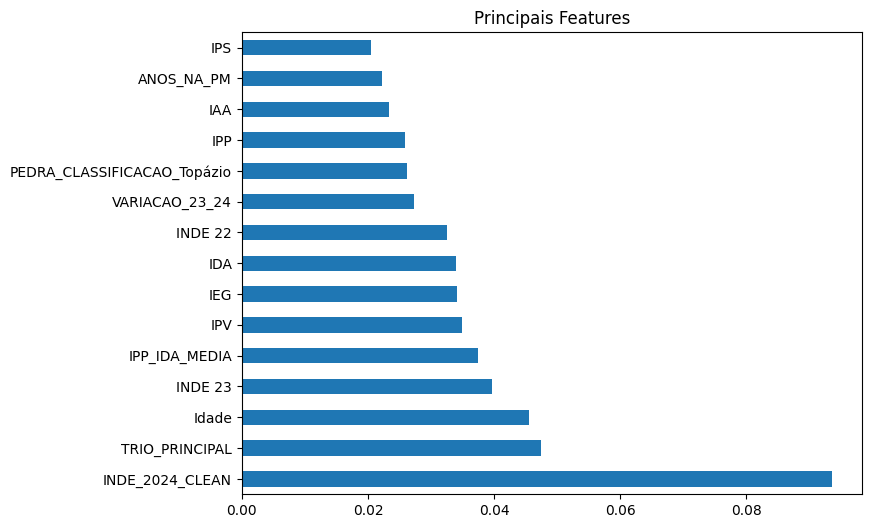

In [21]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,6))
plt.title("Principais Features")
plt.show()


INDE_2024_CLEAN se torna uma feature muito importante por ser ponderado nos indicadores IAN, IDA< IEG, IAA< IPS, IPP e IPV.

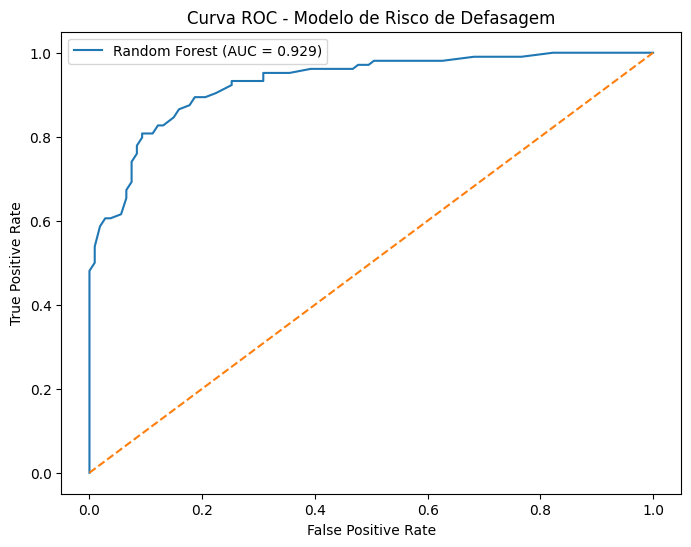

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo de Risco de Defasagem")

plt.legend()
plt.show()


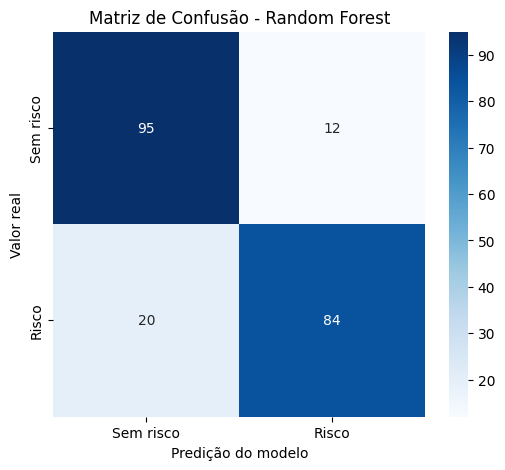

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sem risco","Risco"],
    yticklabels=["Sem risco","Risco"]
)

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Matriz de Confusão - Random Forest")

plt.show()
